2026-04-14 14:40:03.734957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776177603.973670      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776177604.037530      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776177604.574048      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776177604.574088      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776177604.574091      23 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1776177632.683762      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776177632.690127      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1776177636.589711      71 service.cc:152] XLA service 0x7b8ec800ba10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776177636.589746      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776177636.589750      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776177636.989559      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


  65/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0811 - mse: 0.0811

I0000 00:00:1776177638.283504      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0387 - mse: 0.0387
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0210 - mse: 0.0210
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0191 - mse: 0.0191
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0178 - mse: 0.0178
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0172 - mse: 0.0172
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0168 - mse: 0.0168
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0165 - mse: 0.0165
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - mse: 0.0162
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0159 - mse: 0.0159
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0154 - mse: 0.0154
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0153 - mse: 0.0153
Epoch 12/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0151 - mse: 0.0151
Epoch 13/20


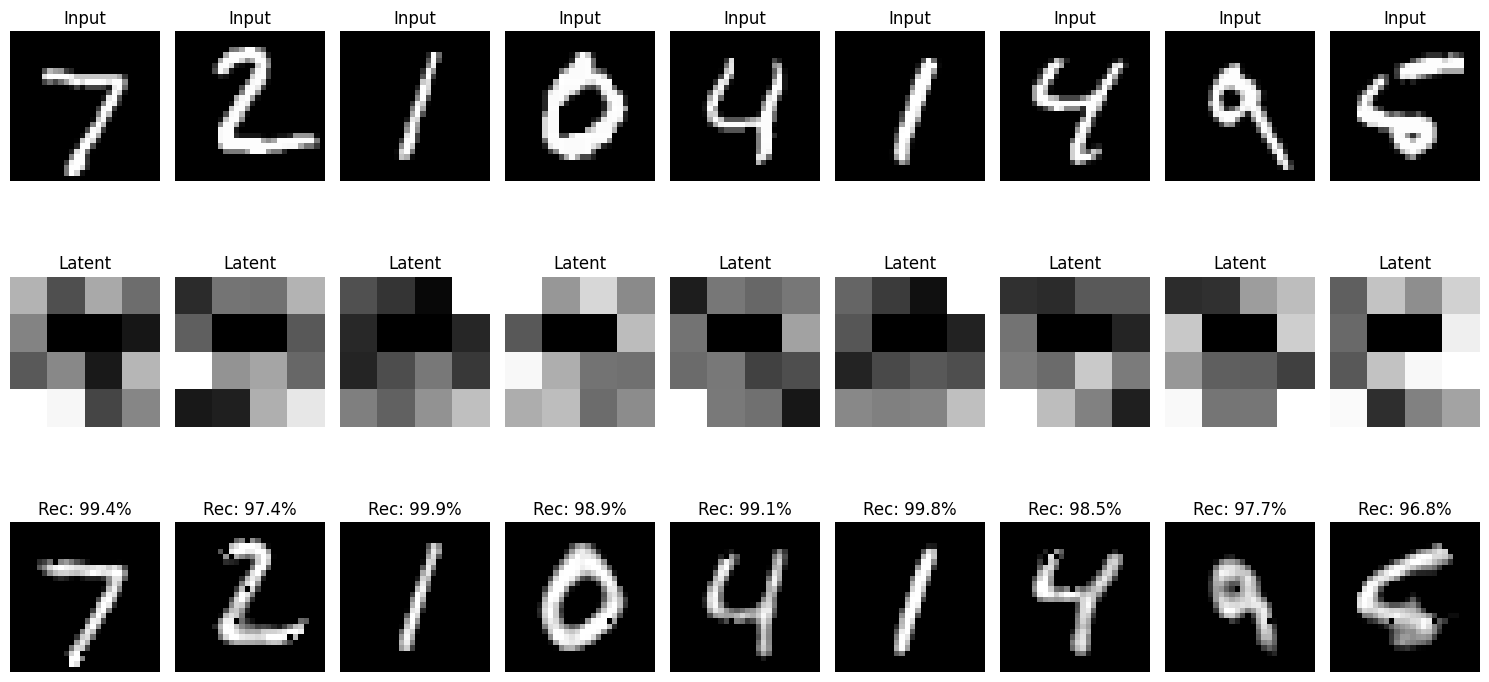

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Load data
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten input
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Encoder
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(32,activation='relu')(encoded)
encoded = Dense(16,activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(784, activation='relu')(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Separate encoder model
encoder = Model(input_img, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse', metrics=['mse'])

# Train
autoencoder.fit(X_train, X_train, epochs=20, batch_size=32, shuffle=True)

# Get encoded and decoded images
encoded_imgs = encoder.predict(X_test[:9])
decoded_imgs = autoencoder.predict(X_test[:9])
decoded_imgs = np.clip(decoded_imgs, 0, 1)

plt.figure(figsize=(15, 8))

for i in range(9):
    # Original Image
    ax = plt.subplot(3, 9, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Input")
    plt.axis('off')

    # Encoded Representation
    ax = plt.subplot(3, 9, 9 + i + 1)
    plt.imshow(encoded_imgs[i].reshape(4, 4), cmap='gray')
    plt.title("Latent")
    plt.axis('off')

    # Decoded Image + Similarity Score
    ax = plt.subplot(3, 9, 18 + i + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    
    # Calculate MSE and a simple "Confidence" score (1 - MSE)
    mse = mean_squared_error(X_test[i], decoded_imgs[i])
    confidence = max(0, (1 - mse) * 100) # Simple percentage representation
    
    plt.title(f"Rec: {confidence:.1f}%")
    plt.axis('off')

plt.tight_layout()
plt.show()

above used architecture is, one dense layer with relu activation to encode followed by decode layer with same relu as activation function, as we dealing with values from 0 to infinite the loss function binary_crossentropy is not fisible so we are using mse as our loss function

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3344
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2641
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2596
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2396
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2244
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2121
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2011
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1944
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1883
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1845
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


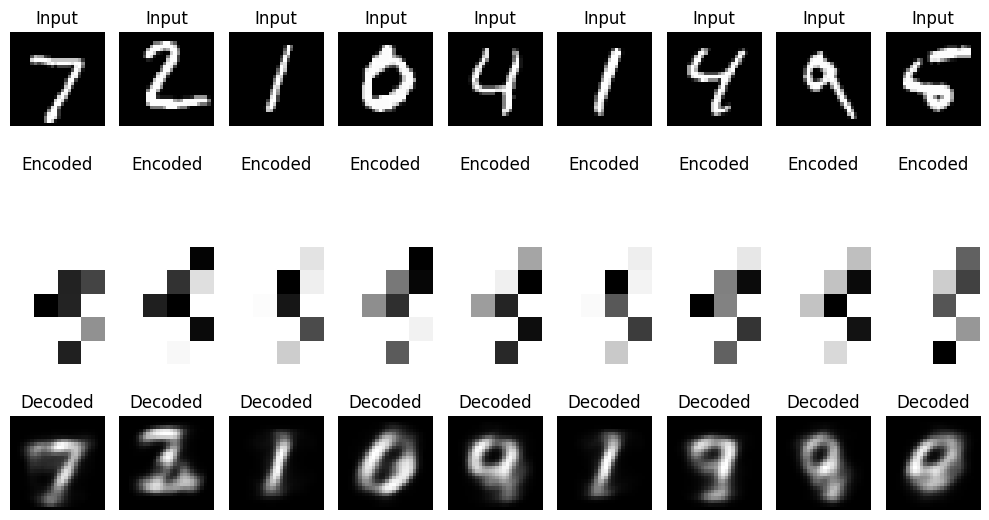

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load data
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten input
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Encoder
input_img = Input(shape=(784,))
encoded = Dense(32, activation='sigmoid')(input_img)
#encoded = Dense(64, activation='relu')(encoded)  # latent space
#encoded = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(784, activation='sigmoid')(encoded)
#decoded = Dense(128, activation='relu')(decoded)
#decoded = Dense(784, activation='relu')(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Separate encoder model
encoder = Model(input_img, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, shuffle=True)

# Get encoded and decoded images
encoded_imgs = encoder.predict(X_test[:9])
decoded_imgs = autoencoder.predict(X_test[:9])

plt.figure(figsize=(10,6))

for i in range(9):
    plt.subplot(3,9,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Input")
    plt.axis('off')

for i in range(9):
    plt.subplot(3,9,9+i+1)
    plt.imshow(encoded_imgs[i].reshape(8,4), cmap='gray')  # 32 → 8x4
    plt.title("Encoded")
    plt.axis('off')

for i in range(9):
    plt.subplot(3,9,18+i+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4116
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2111
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1966
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1797
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1733
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1698
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1682
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1663
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1666
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1571
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


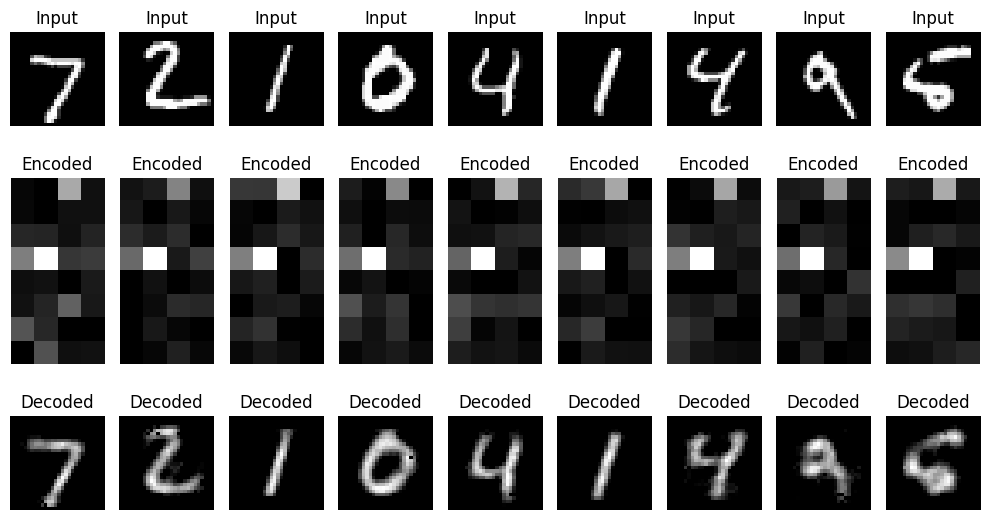

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load data
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten input
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Encoder
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
encoded = Dense(32, activation='relu')(encoded)  # latent space
#encoded = Dense(32, activation='relu')(encoded)

# Decoder
#decoded = Dense(784, activation='sigmoid')(encoded)
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='relu')(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Separate encoder model
encoder = Model(input_img, encoded)

# Compile
autoencoder.compile(optimizer='RMSprop', loss='binary_crossentropy')

# Train
autoencoder.fit(X_train, X_train, epochs=10, batch_size=32, shuffle=True)

# Get encoded and decoded images
encoded_imgs = encoder.predict(X_test[:9])
decoded_imgs = autoencoder.predict(X_test[:9])

plt.figure(figsize=(10,6))

for i in range(9):
    plt.subplot(3,9,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Input")
    plt.axis('off')

for i in range(9):
    plt.subplot(3,9,9+i+1)
    plt.imshow(encoded_imgs[i].reshape(8,4), cmap='gray')  # 32 → 8x4
    plt.title("Encoded")
    plt.axis('off')

for i in range(9):
    plt.subplot(3,9,18+i+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0516 - val_loss: 0.0264
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0259 - val_loss: 0.0237
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0234 - val_loss: 0.0223
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0222 - val_loss: 0.0214
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0213 - val_loss: 0.0207
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0207 - val_loss: 0.0203
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0202 - val_loss: 0.0200
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0200 - val_loss: 0.0197
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0198 - val_loss: 0.0197
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0195
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0193 - val_loss: 0.0192
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

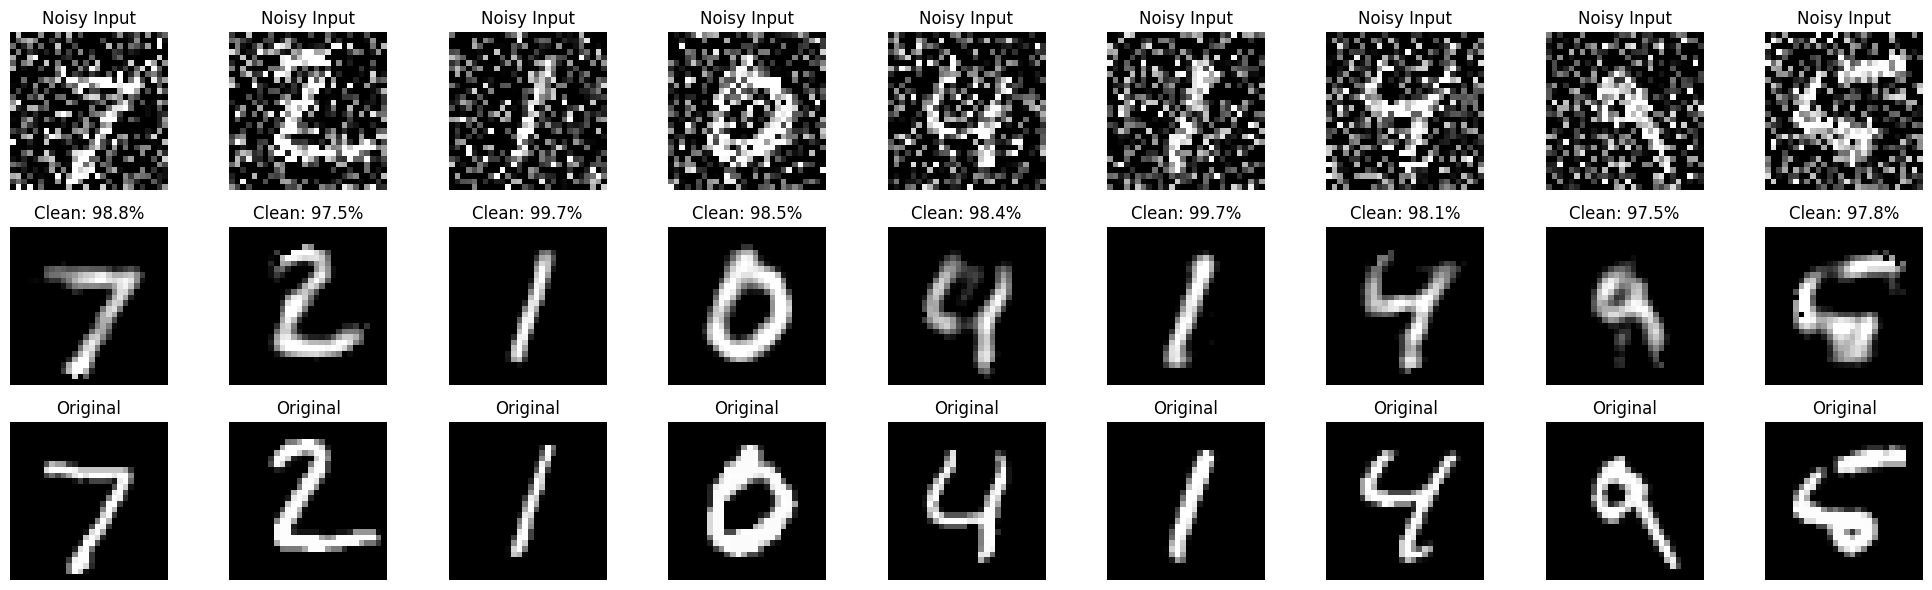

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from sklearn.metrics import mean_squared_error

# 1. Load and Normalize Data
(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# 2. Create Noisy Data
noise_factor = 0.5
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape) 
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape) 

# Ensure pixel values stay within [0, 1]
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# 3. Build the Denoising Autoencoder
input_img = Input(shape=(784,))
# Encoder
x = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(x)  # Latent space

# Decoder
x = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='relu')(x) 

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# 4. Train: Map Noisy Input -> Clean Output
autoencoder.fit(X_train_noisy, X_train, 
                epochs=20, 
                batch_size=128, 
                shuffle=True, 
                validation_data=(X_test_noisy, X_test))

# 5. Prediction & Visualization
decoded_imgs = autoencoder.predict(X_test_noisy[:9])
decoded_imgs = np.clip(decoded_imgs, 0, 1)

plt.figure(figsize=(20, 6))
for i in range(9):
    # Display Noisy Input
    ax = plt.subplot(3, 9, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input")
    plt.axis('off')

    # Display Denoised Output
    ax = plt.subplot(3, 9, 9 + i + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    
    # Reconstruction Confidence (1 - MSE)
    mse = mean_squared_error(X_test[i], decoded_imgs[i])
    confidence = max(0, (1 - mse) * 100)
    
    plt.title(f"Clean: {confidence:.1f}%")
    plt.axis('off')

    # Display Original (Ground Truth)
    ax = plt.subplot(3, 9, 18 + i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


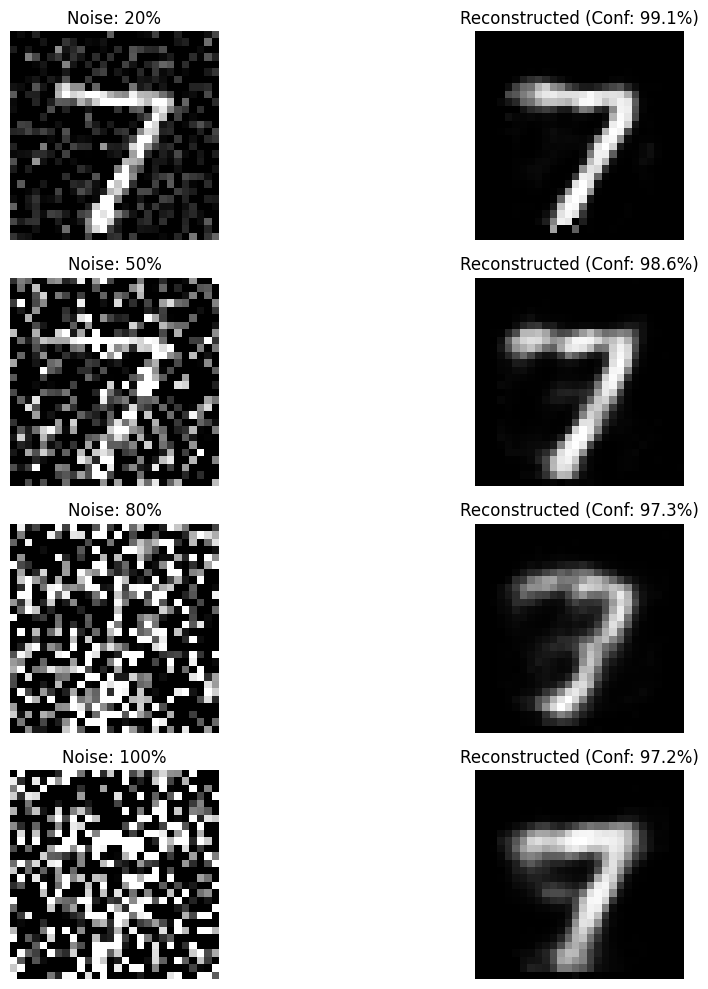

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from sklearn.metrics import mean_squared_error

# Load data
(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.
X_test = X_test.reshape(-1, 784).astype('float32') / 255.

def train_and_test_denoising(noise_level):
    # Add noise
    X_train_noisy = np.clip(X_train + noise_level * np.random.normal(size=X_train.shape), 0., 1.)
    X_test_noisy = np.clip(X_test + noise_level * np.random.normal(size=X_test.shape), 0., 1.)

    # Model
    input_img = Input(shape=(784,))
    encoded = Dense(256, activation='relu')(input_img) # Higher capacity for higher noise
    encoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(256, activation='relu')(encoded)
    decoded = Dense(784, activation='sigmoid')(decoded) # Sigmoid keeps pixels 0-1

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # Quick train for experiment (5 epochs)
    autoencoder.fit(X_train_noisy, X_train, epochs=5, batch_size=256, verbose=0)
    
    return X_test_noisy, autoencoder.predict(X_test_noisy)

# Test levels: 20%, 50%, 80%, and 100% noise
noise_levels = [0.2, 0.5, 0.8, 1.0]
plt.figure(figsize=(12, 10))

for i, level in enumerate(noise_levels):
    noisy, cleaned = train_and_test_denoising(level)
    
    # Plot Noisy
    plt.subplot(len(noise_levels), 2, 2*i + 1)
    plt.imshow(noisy[0].reshape(28,28), cmap='gray')
    plt.title(f"Noise: {int(level*100)}%")
    plt.axis('off')
    
    # Plot Cleaned
    plt.subplot(len(noise_levels), 2, 2*i + 2)
    plt.imshow(cleaned[0].reshape(28,28), cmap='gray')
    mse = mean_squared_error(X_test[0], cleaned[0])
    plt.title(f"Reconstructed (Conf: {(1-mse)*100:.1f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()